In [44]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

In [2]:
orders = pd.read_csv(r"C:\Users\LENOVO\Downloads\Olist_ecom\olist_orders_dataset.csv")
sellers = pd.read_csv(r"C:\Users\LENOVO\Downloads\Olist_ecom\olist_sellers_dataset.csv")
customers = pd.read_csv(r"C:\Users\LENOVO\Downloads\Olist_ecom\olist_customers_dataset.csv")
reviews = pd.read_csv(r"C:\Users\LENOVO\Downloads\Olist_ecom\olist_order_reviews_dataset.csv")

In [3]:
orders.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 99441 entries, 0 to 99440
Data columns (total 8 columns):
 #   Column                         Non-Null Count  Dtype 
---  ------                         --------------  ----- 
 0   order_id                       99441 non-null  object
 1   customer_id                    99441 non-null  object
 2   order_status                   99441 non-null  object
 3   order_purchase_timestamp       99441 non-null  object
 4   order_approved_at              99281 non-null  object
 5   order_delivered_carrier_date   97658 non-null  object
 6   order_delivered_customer_date  96476 non-null  object
 7   order_estimated_delivery_date  99441 non-null  object
dtypes: object(8)
memory usage: 6.1+ MB


In [5]:
orders.isnull().sum()

order_id                            0
customer_id                         0
order_status                        0
order_purchase_timestamp            0
order_approved_at                 160
order_delivered_carrier_date     1783
order_delivered_customer_date    2965
order_estimated_delivery_date       0
dtype: int64

In [7]:
orders.head(10)

,order_id,customer_id,order_status,order_purchase_timestamp,order_approved_at,order_delivered_carrier_date,order_delivered_customer_date,order_estimated_delivery_date
0,e481f51cbdc54678b7cc49136f2d6af7,9ef432eb6251297304e76186b10a928d,delivered,2017-10-02 10:56:33,2017-10-02 11:07:15,2017-10-04 19:55:00,2017-10-10 21:25:13,2017-10-18 00:00:00
1,53cdb2fc8bc7dce0b6741e2150273451,b0830fb4747a6c6d20dea0b8c802d7ef,delivered,2018-07-24 20:41:37,2018-07-26 03:24:27,2018-07-26 14:31:00,2018-08-07 15:27:45,2018-08-13 00:00:00
2,47770eb9100c2d0c44946d9cf07ec65d,41ce2a54c0b03bf3443c3d931a367089,delivered,2018-08-08 08:38:49,2018-08-08 08:55:23,2018-08-08 13:50:00,2018-08-17 18:06:29,2018-09-04 00:00:00
3,949d5b44dbf5de918fe9c16f97b45f8a,f88197465ea7920adcdbec7375364d82,delivered,2017-11-18 19:28:06,2017-11-18 19:45:59,2017-11-22 13:39:59,2017-12-02 00:28:42,2017-12-15 00:00:00
4,ad21c59c0840e6cb83a9ceb5573f8159,8ab97904e6daea8866dbdbc4fb7aad2c,delivered,2018-02-13 21:18:39,2018-02-13 22:20:29,2018-02-14 19:46:34,2018-02-16 18:17:02,2018-02-26 00:00:00
5,a4591c265e18cb1dcee52889e2d8acc3,503740e9ca751ccdda7ba28e9ab8f608,delivered,2017-07-09 21:57:05,2017-07-09 22:10:13,2017-07-11 14:58:04,2017-07-26 10:57:55,2017-08-01 00:00:00
6,136cce7faa42fdb2cefd53fdc79a6098,ed0271e0b7da060a393796590e7b737a,invoiced,2017-04-11 12:22:08,2017-04-13 13:25:17,NaN,NaN,2017-05-09 00:00:00
7,6514b8ad8028c9f2cc2374ded245783f,9bdf08b4b3b52b5526ff42d37d47f222,delivered,2017-05-16 13:10:30,2017-05-16 13:22:11,2017-05-22 10:07:46,2017-05-26 12:55:51,2017-06-07 00:00:00
8,76c6e866289321a7c93b82b54852dc33,f54a9f0e6b351c431402b8461ea51999,delivered,2017-01-23 18:29:09,2017-01-25 02:50:47,2017-01-26 14:16:31,2017-02-02 14:08:10,2017-03-06 00:00:00
9,e69bfb5eb88e0ed6a785585b27e16dbf,31ad1d1b63eb9962463f764d4e6e0c9d,delivered,2017-07-29 11:55:02,2017-07-29 12:05:32,2017-08-10 19:45:24,2017-08-16 17:14:30,2017-08-23 00:00:00


In [9]:
orders.columns

Index(['order_id', 'customer_id', 'order_status', 'order_purchase_timestamp',
       'order_approved_at', 'order_delivered_carrier_date',
       'order_delivered_customer_date', 'order_estimated_delivery_date'],
      dtype='object')

In [12]:
orders['order_status'].value_counts()

order_status
delivered      96478
shipped         1107
canceled         625
unavailable      609
invoiced         314
processing       301
created            5
approved           2
Name: count, dtype: int64

In [15]:
orders = orders[orders['order_status'] == 'delivered'].copy()

In [16]:
orders['order_status'].value_counts()

order_status
delivered    96478
Name: count, dtype: int64

In [17]:
orders.isnull().sum()

order_id                          0
customer_id                       0
order_status                      0
order_purchase_timestamp          0
order_approved_at                14
order_delivered_carrier_date      2
order_delivered_customer_date     8
order_estimated_delivery_date     0
dtype: int64

In [18]:
orders[orders['order_delivered_customer_date'].isna()]

,order_id,customer_id,order_status,order_purchase_timestamp,order_approved_at,order_delivered_carrier_date,order_delivered_customer_date,order_estimated_delivery_date
3002,2d1e2d5bf4dc7227b3bfebb81328c15f,ec05a6d8558c6455f0cbbd8a420ad34f,delivered,2017-11-28 17:44:07,2017-11-28 17:56:40,2017-11-30 18:12:23,NaN,2017-12-18 00:00:00
20618,f5dd62b788049ad9fc0526e3ad11a097,5e89028e024b381dc84a13a3570decb4,delivered,2018-06-20 06:58:43,2018-06-20 07:19:05,2018-06-25 08:05:00,NaN,2018-07-16 00:00:00
43834,2ebdfc4f15f23b91474edf87475f108e,29f0540231702fda0cfdee0a310f11aa,delivered,2018-07-01 17:05:11,2018-07-01 17:15:12,2018-07-03 13:57:00,NaN,2018-07-30 00:00:00
79263,e69f75a717d64fc5ecdfae42b2e8e086,cfda40ca8dd0a5d486a9635b611b398a,delivered,2018-07-01 22:05:55,2018-07-01 22:15:14,2018-07-03 13:57:00,NaN,2018-07-30 00:00:00
82868,0d3268bad9b086af767785e3f0fc0133,4f1d63d35fb7c8999853b2699f5c7649,delivered,2018-07-01 21:14:02,2018-07-01 21:29:54,2018-07-03 09:28:00,NaN,2018-07-24 00:00:00
92643,2d858f451373b04fb5c984a1cc2defaf,e08caf668d499a6d643dafd7c5cc498a,delivered,2017-05-25 23:22:43,2017-05-25 23:30:16,NaN,NaN,2017-06-23 00:00:00
97647,ab7c89dc1bf4a1ead9d6ec1ec8968a84,dd1b84a7286eb4524d52af4256c0ba24,delivered,2018-06-08 12:09:39,2018-06-08 12:36:39,2018-06-12 14:10:00,NaN,2018-06-26 00:00:00
98038,20edc82cf5400ce95e1afacc25798b31,28c37425f1127d887d7337f284080a0f,delivered,2018-06-27 16:09:12,2018-06-27 16:29:30,2018-07-03 19:26:00,NaN,2018-07-19 00:00:00


In [27]:
orders = orders.dropna(subset = ['order_delivered_customer_date','order_delivered_carrier_date'])

In [74]:
date_cols = [
    'order_purchase_timestamp',
    'order_approved_at',
    'order_delivered_carrier_date',
    'order_delivered_customer_date',
    'order_estimated_delivery_date'
]

for col in date_cols:
    orders[col] = pd.to_datetime(orders[col])

In [75]:
orders.info()

<class 'pandas.core.frame.DataFrame'>
Index: 96469 entries, 0 to 99440
Data columns (total 10 columns):
 #   Column                         Non-Null Count  Dtype         
---  ------                         --------------  -----         
 0   order_id                       96469 non-null  object        
 1   customer_id                    96469 non-null  object        
 2   order_status                   96469 non-null  object        
 3   order_purchase_timestamp       96469 non-null  datetime64[ns]
 4   order_approved_at              96455 non-null  datetime64[ns]
 5   order_delivered_carrier_date   96469 non-null  datetime64[ns]
 6   order_delivered_customer_date  96469 non-null  datetime64[ns]
 7   order_estimated_delivery_date  96469 non-null  datetime64[ns]
 8   delivery_days                  96469 non-null  int64         
 9   delay_days                     96469 non-null  object        
dtypes: datetime64[ns](5), int64(1), object(4)
memory usage: 8.1+ MB


In [76]:
#First KPI Delivery Days
orders['delivery_days'] = (orders['order_delivered_customer_date'] - orders['order_purchase_timestamp']).dt.days

In [77]:
orders[['order_purchase_timestamp',
        'order_delivered_customer_date']].dtypes

order_purchase_timestamp         datetime64[ns]
order_delivered_customer_date    datetime64[ns]
dtype: object

In [78]:
orders['delivery_days'].describe()

count    96469.000000
mean        12.093191
std          9.550565
min          0.000000
25%          6.000000
50%         10.000000
75%         15.000000
max        209.000000
Name: delivery_days, dtype: float64

In [79]:
orders.sort_values(
    by = 'delivery_days',
    ascending = False
)[[
    'order_id',
    'order_purchase_timestamp',
    'order_delivered_customer_date',
    'delivery_days'
]].head(10)

,order_id,order_purchase_timestamp,order_delivered_customer_date,delivery_days
19590,ca07593549f1816d26a572e06dc1eab6,2017-02-21 23:31:27,2017-09-19 14:36:39,209
55619,1b3190b2dfa9d789e1f14c05b647a14a,2018-02-23 14:57:35,2018-09-19 23:24:07,208
61610,440d0d17af552815d15a9e41abe49359,2017-03-07 23:59:51,2017-09-19 15:12:50,195
70307,2fb597c2f772eca01b1f5c561bf6cc7b,2017-03-08 18:09:02,2017-09-19 14:33:17,194
89130,285ab9426d6982034523a855f55a885e,2017-03-08 22:47:40,2017-09-19 14:00:04,194
38509,0f4519c5f1c541ddec9f21b3bddd533a,2017-03-09 13:26:57,2017-09-19 14:38:21,194
11399,47b40429ed8cce3aee9199792275433f,2018-01-03 09:44:01,2018-07-13 20:51:31,191
81401,2fe324febf907e3ea3f2aa9650869fa5,2017-03-13 20:17:10,2017-09-19 17:00:07,189
54480,2d7561026d542c8dbd8f0daeadf67a43,2017-03-15 11:24:27,2017-09-19 14:38:18,188
62286,437222e3fd1b07396f1d9ba8c15fba59,2017-03-16 11:36:00,2017-09-19 16:28:58,187


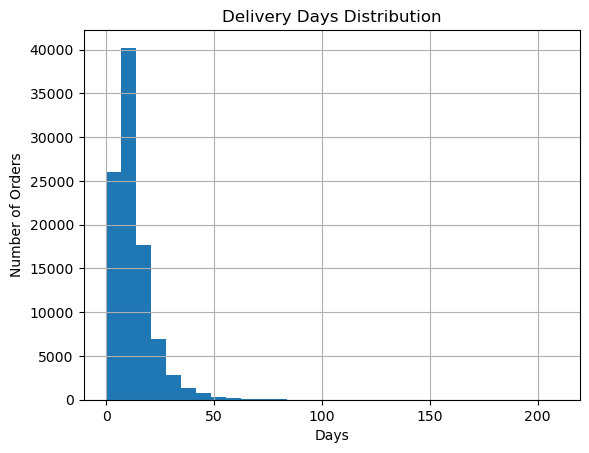

In [80]:
orders['delivery_days'].hist(bins=30)

plt.title('Delivery Days Distribution')
plt.xlabel('Days')
plt.ylabel('Number of Orders')
plt.show()

In [103]:
#Second KPI Delay Analysis
orders['delay_days'] = (
    orders['order_delivered_customer_date'] - orders['order_estimated_delivery_date']
).dt.days

In [104]:
orders['delay_days'].describe()

count    96469.000000
mean       -11.876074
std         10.181995
min       -147.000000
25%        -17.000000
50%        -12.000000
75%         -7.000000
max        188.000000
Name: delay_days, dtype: float64

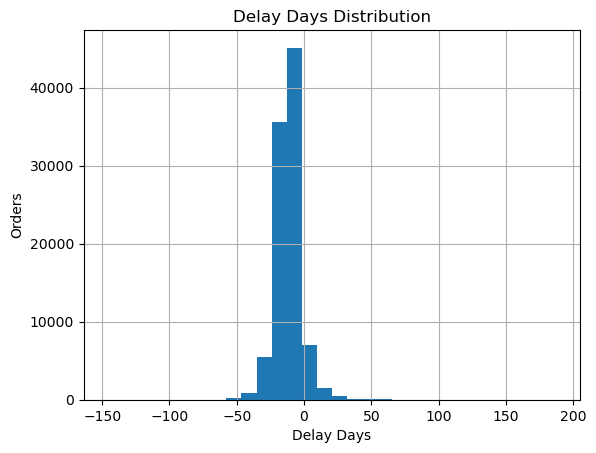

In [105]:
orders['delay_days'].hist(bins=30)
plt.title('Delay Days Distribution')
plt.xlabel('Delay Days')
plt.ylabel('Orders')
plt.show()

In [106]:
delayed_orders = orders[orders['delay_days'] > 0]

len(delayed_orders)

6533

In [107]:
delay_percentage = (
    len(delayed_orders)/len(orders)
)*100
print(delay_percentage)

6.77212368740217


In [108]:
orders['delay_category'] = np.where(
    orders['delay_days']>0,
    'Delayed',
    'Ontime/Early'
)

In [110]:
orders['delay_category'].value_counts()

delay_category
Ontime/Early    89936
Delayed          6533
Name: count, dtype: int64

In [111]:
customers.head(10)

,customer_id,customer_unique_id,customer_zip_code_prefix,customer_city,customer_state
0,06b8999e2fba1a1fbc88172c00ba8bc7,861eff4711a542e4b93843c6dd7febb0,14409,franca,SP
1,18955e83d337fd6b2def6b18a428ac77,290c77bc529b7ac935b93aa66c333dc3,9790,sao bernardo do campo,SP
2,4e7b3e00288586ebd08712fdd0374a03,060e732b5b29e8181a18229c7b0b2b5e,1151,sao paulo,SP
3,b2b6027bc5c5109e529d4dc6358b12c3,259dac757896d24d7702b9acbbff3f3c,8775,mogi das cruzes,SP
4,4f2d8ab171c80ec8364f7c12e35b23ad,345ecd01c38d18a9036ed96c73b8d066,13056,campinas,SP
5,879864dab9bc3047522c92c82e1212b8,4c93744516667ad3b8f1fb645a3116a4,89254,jaragua do sul,SC
6,fd826e7cf63160e536e0908c76c3f441,addec96d2e059c80c30fe6871d30d177,4534,sao paulo,SP
7,5e274e7a0c3809e14aba7ad5aae0d407,57b2a98a409812fe9618067b6b8ebe4f,35182,timoteo,MG
8,5adf08e34b2e993982a47070956c5c65,1175e95fb47ddff9de6b2b06188f7e0d,81560,curitiba,PR
9,4b7139f34592b3a31687243a302fa75b,9afe194fb833f79e300e37e580171f22,30575,belo horizonte,MG


In [112]:
orders_customers = orders.merge(
    customers,
    on='customer_id',
    how='left'
)

In [113]:
orders_customers['delay_days'].describe()

count    96469.000000
mean       -11.876074
std         10.181995
min       -147.000000
25%        -17.000000
50%        -12.000000
75%         -7.000000
max        188.000000
Name: delay_days, dtype: float64

In [114]:
orders_customers.shape

(96469, 15)

In [115]:
orders_customers.head()

,order_id,customer_id,order_status,order_purchase_timestamp,order_approved_at,order_delivered_carrier_date,order_delivered_customer_date,order_estimated_delivery_date,delivery_days,delay_days,delay_category,customer_unique_id,customer_zip_code_prefix,customer_city,customer_state
0,e481f51cbdc54678b7cc49136f2d6af7,9ef432eb6251297304e76186b10a928d,delivered,2017-10-02 10:56:33,2017-10-02 11:07:15,2017-10-04 19:55:00,2017-10-10 21:25:13,2017-10-18,8,-8,Ontime/Early,7c396fd4830fd04220f754e42b4e5bff,3149,sao paulo,SP
1,53cdb2fc8bc7dce0b6741e2150273451,b0830fb4747a6c6d20dea0b8c802d7ef,delivered,2018-07-24 20:41:37,2018-07-26 03:24:27,2018-07-26 14:31:00,2018-08-07 15:27:45,2018-08-13,13,-6,Ontime/Early,af07308b275d755c9edb36a90c618231,47813,barreiras,BA
2,47770eb9100c2d0c44946d9cf07ec65d,41ce2a54c0b03bf3443c3d931a367089,delivered,2018-08-08 08:38:49,2018-08-08 08:55:23,2018-08-08 13:50:00,2018-08-17 18:06:29,2018-09-04,9,-18,Ontime/Early,3a653a41f6f9fc3d2a113cf8398680e8,75265,vianopolis,GO
3,949d5b44dbf5de918fe9c16f97b45f8a,f88197465ea7920adcdbec7375364d82,delivered,2017-11-18 19:28:06,2017-11-18 19:45:59,2017-11-22 13:39:59,2017-12-02 00:28:42,2017-12-15,13,-13,Ontime/Early,7c142cf63193a1473d2e66489a9ae977,59296,sao goncalo do amarante,RN
4,ad21c59c0840e6cb83a9ceb5573f8159,8ab97904e6daea8866dbdbc4fb7aad2c,delivered,2018-02-13 21:18:39,2018-02-13 22:20:29,2018-02-14 19:46:34,2018-02-16 18:17:02,2018-02-26,2,-10,Ontime/Early,72632f0f9dd73dfee390c9b22eb56dd6,9195,santo andre,SP


In [116]:
orders_customers['delay_days'].dtype

dtype('int64')

In [117]:
orders_customers[['delay_days']].info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 96469 entries, 0 to 96468
Data columns (total 1 columns):
 #   Column      Non-Null Count  Dtype
---  ------      --------------  -----
 0   delay_days  96469 non-null  int64
dtypes: int64(1)
memory usage: 753.8 KB


In [118]:
orders_customers['delay_days'] = pd.to_numeric(
    orders_customers['delay_days'],
    errors='coerce'
)

In [119]:
orders_customers['delay_days'].dtype

dtype('int64')

In [126]:
state_delay = (
    orders_customers
    .groupby('customer_state')['delay_days']
    .mean()
    .sort_values(ascending=False)
)

state_delay.head(10)

customer_state
AL    -8.707809
MA    -9.571827
SE   -10.020896
ES   -10.496241
BA   -10.794533
CE   -10.804535
MS   -11.052782
SP   -11.075964
PI   -11.306723
SC   -11.503384
Name: delay_days, dtype: float64

In [127]:
state_delivery = (
    orders_customers
    .groupby('customer_state')['delivery_days']
    .mean()
    .sort_values(ascending=False)
)

state_delivery.head(10)

customer_state
RR    28.975610
AP    26.731343
AM    25.986207
AL    24.040302
PA    23.316068
MA    21.117155
SE    21.029851
CE    20.817826
AC    20.637500
PB    19.953578
Name: delivery_days, dtype: float64

In [131]:
orders_reviews = orders.merge(
    reviews,
    on = 'order_id',
    how = 'left'
)

In [132]:
orders_reviews.groupby(
    'review_score'
)['delay_days'].mean()

review_score
1.0    -4.048060
2.0    -8.634818
3.0   -10.776912
4.0   -12.380840
5.0   -13.387939
Name: delay_days, dtype: float64

In [140]:
items = pd.read_csv(r"C:\Users\LENOVO\Downloads\Olist_ecom\olist_order_items_dataset.csv")
items.head()

,order_id,order_item_id,product_id,seller_id,shipping_limit_date,price,freight_value
0,00010242fe8c5a6d1ba2dd792cb16214,1,4244733e06e7ecb4970a6e2683c13e61,48436dade18ac8b2bce089ec2a041202,2017-09-19 09:45:35,58.90,13.29
1,00018f77f2f0320c557190d7a144bdd3,1,e5f2d52b802189ee658865ca93d83a8f,dd7ddc04e1b6c2c614352b383efe2d36,2017-05-03 11:05:13,239.90,19.93
2,000229ec398224ef6ca0657da4fc703e,1,c777355d18b72b67abbeef9df44fd0fd,5b51032eddd242adc84c38acab88f23d,2018-01-18 14:48:30,199.00,17.87
3,00024acbcdf0a6daa1e931b038114c75,1,7634da152a4610f1595efa32f14722fc,9d7a1d34a5052409006425275ba1c2b4,2018-08-15 10:10:18,12.99,12.79
4,00042b26cf59d7ce69dfabb4e55b4fd9,1,ac6c3623068f30de03045865e4e10089,df560393f3a51e74553ab94004ba5c87,2017-02-13 13:57:51,199.90,18.14


In [143]:
route_df = (
    orders
    .merge(
        items[['order_id', 'seller_id']],
        on = 'order_id',
        how = 'left'
    )
    .merge(
        sellers[['seller_id', 'seller_state']],
        on = 'seller_id',
        how = 'left'
    )
    .merge(
        customers[['customer_id', 'customer_state']],
        on = 'customer_id',
        how = 'left'
    )
)

In [144]:
route_df.shape

(110188, 14)

In [145]:
route_df[['seller_state','customer_state']].head()

,seller_state,customer_state
0,SP,SP
1,SP,BA
2,SP,GO
3,MG,RN
4,SP,SP


In [155]:
route_df['route'] = (
    route_df['seller_state'] + ' -> ' + route_df['customer_state']
)

In [156]:
route_df.head()

,order_id,customer_id,order_status,order_purchase_timestamp,order_approved_at,order_delivered_carrier_date,order_delivered_customer_date,order_estimated_delivery_date,delivery_days,delay_days,delay_category,seller_id,seller_state,customer_state,route
0,e481f51cbdc54678b7cc49136f2d6af7,9ef432eb6251297304e76186b10a928d,delivered,2017-10-02 10:56:33,2017-10-02 11:07:15,2017-10-04 19:55:00,2017-10-10 21:25:13,2017-10-18,8,-8,Ontime/Early,3504c0cb71d7fa48d967e0e4c94d59d9,SP,SP,SP -> SP
1,53cdb2fc8bc7dce0b6741e2150273451,b0830fb4747a6c6d20dea0b8c802d7ef,delivered,2018-07-24 20:41:37,2018-07-26 03:24:27,2018-07-26 14:31:00,2018-08-07 15:27:45,2018-08-13,13,-6,Ontime/Early,289cdb325fb7e7f891c38608bf9e0962,SP,BA,SP -> BA
2,47770eb9100c2d0c44946d9cf07ec65d,41ce2a54c0b03bf3443c3d931a367089,delivered,2018-08-08 08:38:49,2018-08-08 08:55:23,2018-08-08 13:50:00,2018-08-17 18:06:29,2018-09-04,9,-18,Ontime/Early,4869f7a5dfa277a7dca6462dcf3b52b2,SP,GO,SP -> GO
3,949d5b44dbf5de918fe9c16f97b45f8a,f88197465ea7920adcdbec7375364d82,delivered,2017-11-18 19:28:06,2017-11-18 19:45:59,2017-11-22 13:39:59,2017-12-02 00:28:42,2017-12-15,13,-13,Ontime/Early,66922902710d126a0e7d26b0e3805106,MG,RN,MG -> RN
4,ad21c59c0840e6cb83a9ceb5573f8159,8ab97904e6daea8866dbdbc4fb7aad2c,delivered,2018-02-13 21:18:39,2018-02-13 22:20:29,2018-02-14 19:46:34,2018-02-16 18:17:02,2018-02-26,2,-10,Ontime/Early,2c9e548be18521d1c43cde1c582c6de8,SP,SP,SP -> SP


In [157]:
route_delay = (
    route_df
    .groupby('route')['delay_days']
    .mean()
    .sort_values(ascending=False)
)

route_delay.head(10)

route
CE -> AM    104.000000
AM -> AL     38.000000
BA -> AC     24.000000
ES -> PA      1.666667
MA -> SE      0.800000
MA -> AL      0.750000
CE -> PI      0.333333
PB -> AL      0.000000
AM -> MA      0.000000
MA -> PB     -0.750000
Name: delay_days, dtype: float64

In [193]:
route_stats = (
    route_df
    .groupby('route')
    .agg(
        avg_delay=('delay_days','mean'),
        avg_delivery=('delivery_days', 'mean'),
        total_orders=('order_id','count')
    )
)

In [194]:
route_stats.sort_values(
    'avg_delay',
    ascending=False
).head(20)

,avg_delay,avg_delivery,total_orders
route,,,
CE -> AM,104.000000,138.000000,1
AM -> AL,38.000000,90.000000,1
BA -> AC,24.000000,66.000000,1
ES -> PA,1.666667,36.333333,3
MA -> SE,0.800000,29.000000,5
MA -> AL,0.750000,29.750000,4
CE -> PI,0.333333,27.666667,3
PB -> AL,0.000000,31.000000,1
AM -> MA,0.000000,29.000000,1


In [195]:
route_stats = route_stats[route_stats['total_orders']>=30]

In [196]:
route_stats.sort_values(
    'avg_delay',
    ascending=False
).head(15)


,avg_delay,avg_delivery,total_orders
route,,,
PR -> AL,-4.325581,30.627907,43
RJ -> CE,-5.125000,25.535714,56
DF -> DF,-7.573770,5.622951,61
SP -> AL,-8.241758,24.095238,273
GO -> GO,-9.179487,4.948718,39
MG -> SE,-9.365854,24.585366,41
SP -> SE,-9.375527,20.848101,237
BA -> BA,-9.418919,10.662162,74
SP -> MA,-9.551913,21.779599,549


In [197]:
top_routes = (
    route_df.groupby("route")["order_id"]
    .count()
    .sort_values(ascending=False)
)

top_routes.head(10)

route
SP -> SP    35420
SP -> RJ     9403
SP -> MG     8567
SP -> RS     4133
SP -> PR     3609
PR -> SP     3339
MG -> SP     2900
SP -> SC     2709
SP -> BA     2626
MG -> MG     1669
Name: order_id, dtype: int64

In [199]:
orders_reviews_customers = (
    orders_reviews.merge(
        customers,
        on="customer_id",
        how="left"
    )
)

state_review_stats = (
    orders_reviews_customers
    .groupby("customer_state")
    .agg(
        avg_review=("review_score", "mean"),
        total_reviews=("review_score", "count")
    )
)

state_review_stats_filtered = (
    state_review_stats[
        state_review_stats["total_reviews"] >= 500
    ]
)


state_review_stats_filtered.sort_values(
    by="avg_review",
    ascending=False
)

,avg_review,total_reviews
customer_state,,
SP,4.246146,40476
PR,4.238260,4919
MG,4.192707,11354
RS,4.185344,5363
MS,4.169014,710
MT,4.147392,882
DF,4.131642,2089
SC,4.131050,3533
GO,4.102904,1963


In [200]:
orders_reviews_customers.to_csv(
    "logistics_dashboard_data.csv",
    index=False
)

In [201]:
import os
print(os.getcwd())

C:\Users\LENOVO


In [202]:
orders_reviews_customers.to_csv(
    r"C:\Users\LENOVO\Downloads\Olist_ecom\logistics_dashboard_data.csv",
    index=False
)

In [205]:
route_stats.to_csv(
    r"C:\Users\LENOVO\Downloads\Olist_ecom\route_stats.csv",
    index=True
)